# Notebook 03 — Malliavin Greeks: Delta Estimation under Heston Dynamics
### Malliavin Calculus for Robust Hedging of Exotic Derivatives
**Robin Guichon — Centrale Nantes, 2025-2026**

---
**Objective:** Estimate the Delta using Malliavin calculus and compare it to finite differences for smooth payoffs (European call) and discontinuous payoffs (digital option).

**Pipeline:**
1. Loading calibrated parameters (Notebook 01) and the Euler FT scheme (Notebook 02)
2. Malliavin weight formula $\hat\pi_\Delta$ under discretized Heston
3. Validation on the European call: Malliavin vs. finite differences vs. semi-analytical reference
4. Digital option Delta: Malliavin vs. finite differences (discontinuous payoff)
5. Variance reduction analysis: Malliavin vs. FD as a function of $N$
6. Delta Smile: moneyness grid, Malliavin vs. semi-analytical
7. Sensitivity to the bump step $h$ (FD) and the number of paths $N$ (Malliavin)
8. Export of figures and tables for Section IV.3 of the thesis

---

## 0. Imports and Configuration

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, gaussian_kde
from scipy.optimize import brentq
from scipy.integrate import quad
import json
import time
import warnings
warnings.filterwarnings('ignore')

# ── Unified document style ────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
cmap   = plt.get_cmap('magma')
C_TEXT = 'black'

def add_arrows(ax):
    ax.plot(1, 0, '>', color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.plot(0, 1, '^', color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.spines['left'].set_color(C_TEXT)
    ax.spines['bottom'].set_color(C_TEXT)
    ax.tick_params(colors=C_TEXT)

np.random.seed(42)
print('Imports OK ✓')

Imports OK ✓


---
## 1. Loading Calibrated Parameters

In [22]:
# ── Loading from Notebook 01 ──────────────────────────────────────────────
try:
    with open('heston_calibrated_params.json', 'r') as f:
        cal = json.load(f)
    print('Calibrated parameters loaded from heston_calibrated_params.json ✓')
except FileNotFoundError:
    print('JSON not found — using reference parameters')
    cal = {
        'kappa': 2.1539, 'theta': 0.0448, 'xi': 0.5507,
        'rho': -0.6229,  'v0': 0.0577,
        'S0': 5000.0, 'r': 0.0525, 'q': 0.013,
        'N_steps_recommended': 252
    }

kappa  = cal['kappa']
theta  = cal['theta']
xi     = cal['xi']
rho    = cal['rho']
v0     = cal['v0']
S0     = cal['S0']
r      = cal['r']
q      = cal.get('q', 0.013)
N_steps = cal.get('N_steps_recommended', 252)

print(f'\nParameters:')
print(f'  κ = {kappa:.4f}   θ = {theta:.4f}   ξ = {xi:.4f}')
print(f'  ρ = {rho:.4f}   v₀ = {v0:.4f}')
print(f'  S₀ = {S0:.1f}   r = {r:.4f}   q = {q:.4f}')
print(f'  Feller: 2κθ = {2*kappa*theta:.4f}  ξ² = {xi**2:.4f}  '
      f'({"OK" if 2*kappa*theta > xi**2 else "Violated — full truncation active"})')
print(f'  N_steps = {N_steps}')

Calibrated parameters loaded from heston_calibrated_params.json ✓

Parameters:
  κ = 2.1539   θ = 0.0448   ξ = 0.5507
  ρ = -0.6229   v₀ = 0.0577
  S₀ = 5000.0   r = 0.0525   q = 0.0130
  Feller: 2κθ = 0.1930  ξ² = 0.3033  (Violated — full truncation active)
  N_steps = 252


---
## 2. Reference Tools

### 2.1 Black-Scholes and Implied Volatility

In [23]:
def bs_price(S, K, T, r, q, sigma, flag='call'):
    if sigma <= 0 or T <= 0:
        return max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if flag == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

def implied_vol(price, S, K, T, r, q, flag='call'):
    intrinsic = max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.) if flag=='call' \
                else max(K*np.exp(-r*T) - S*np.exp(-q*T), 0.)
    if price <= intrinsic + 1e-9 or price >= S:
        return np.nan
    try:
        return brentq(lambda s: bs_price(S, K, T, r, q, s, flag) - price,
                      1e-5, 5.0, xtol=1e-8, maxiter=300)
    except Exception:
        return np.nan

print('Black-Scholes utilities defined ✓')

Black-Scholes utilities defined ✓


### 2.2 Semi-Analytical Pricers and Deltas — Gil-Pelaez

The semi-analytical Delta is obtained by numerical differentiation of the Gil-Pelaez formula:
$$\Delta^{ref} = \frac{\partial}{\partial S_0}\left[e^{-rT} \Pi^{Gil-Pelaez}(S_0, K, T)\right] \approx \frac{\Pi(S_0 + h) - \Pi(S_0 - h)}{2h}$$
with $h = 10^{-4} \cdot S_0$.

In [24]:
def heston_cf_j(phi, j, S, T, r, q, v0, kappa, theta, xi, rho):
    """Characteristic function f_j for Gil-Pelaez."""
    i   = 1j
    x   = np.log(S)
    b   = kappa - rho*xi if j == 1 else kappa
    u   = 0.5  if j == 1 else -0.5
    d   = np.sqrt((rho*xi*i*phi - b)**2 - xi**2*(2*u*i*phi - phi**2))
    g   = (b - rho*xi*i*phi + d) / (b - rho*xi*i*phi - d)
    C   = ((r-q)*i*phi*T
           + kappa*theta/xi**2
           * ((b - rho*xi*i*phi + d)*T
              - 2.*np.log((1. - g*np.exp(d*T))/(1. - g))))
    D   = ((b - rho*xi*i*phi + d)/xi**2
           * (1. - np.exp(d*T))/(1. - g*np.exp(d*T)))
    return np.exp(C + D*v0 + i*phi*x)


def heston_call_reference(S, K, T, r, q, v0, kappa, theta, xi, rho):
    """Semi-analytical price via Gil-Pelaez."""
    def integrand(j, phi):
        return np.real(
            np.exp(-1j*phi*np.log(K))
            * heston_cf_j(phi, j, S, T, r, q, v0, kappa, theta, xi, rho)
            / (1j*phi)
        )
    P1, _ = quad(lambda p: integrand(1, p), 1e-6, 300., limit=300, epsabs=1e-9)
    P2, _ = quad(lambda p: integrand(2, p), 1e-6, 300., limit=300, epsabs=1e-9)
    P1 = 0.5 + P1/np.pi
    P2 = 0.5 + P2/np.pi
    return max(S*np.exp(-q*T)*P1 - K*np.exp(-r*T)*P2, 0.)


def heston_digital_reference(S, K, T, r, q, v0, kappa, theta, xi, rho):
    """
    Reference price of a cash-or-nothing digital option.
    Phi(S_T) = 1_{S_T > K},  price = e^{-rT} * P2.
    """
    def integrand(phi):
        return np.real(
            np.exp(-1j*phi*np.log(K))
            * heston_cf_j(phi, 2, S, T, r, q, v0, kappa, theta, xi, rho)
            / (1j*phi)
        )
    P2, _ = quad(integrand, 1e-6, 300., limit=300, epsabs=1e-9)
    P2 = 0.5 + P2/np.pi
    return np.exp(-r*T) * P2


def heston_delta_reference(S, K, T, r, q, v0, kappa, theta, xi, rho,
                            payoff='call', h_rel=1e-4):
    """
    Semi-analytical Delta by central differences on S₀.
    h_rel: relative bump (default 1e-4).
    """
    h = h_rel * S
    if payoff == 'call':
        pU = heston_call_reference(S+h, K, T, r, q, v0, kappa, theta, xi, rho)
        pD = heston_call_reference(S-h, K, T, r, q, v0, kappa, theta, xi, rho)
    else:
        pU = heston_digital_reference(S+h, K, T, r, q, v0, kappa, theta, xi, rho)
        pD = heston_digital_reference(S-h, K, T, r, q, v0, kappa, theta, xi, rho)
    return (pU - pD) / (2.*h)


# Quick validation
p_ref_atm = heston_call_reference(S0, S0, 1.0, r, q, v0, kappa, theta, xi, rho)
d_ref_atm = heston_digital_reference(S0, S0, 1.0, r, q, v0, kappa, theta, xi, rho)
delta_call_atm = heston_delta_reference(S0, S0, 1.0, r, q, v0, kappa, theta, xi, rho, 'call')
delta_dig_atm  = heston_delta_reference(S0, S0, 1.0, r, q, v0, kappa, theta, xi, rho, 'digital')
print(f'ATM Call (T=1Y): price = {p_ref_atm:.4f}   Δ = {delta_call_atm:.6f}')
print(f'ATM Digital (T=1Y): price = {d_ref_atm:.6f}   Δ = {delta_dig_atm:.8f}')
print('Reference Pricers and Deltas defined ✓')

ATM Call (T=1Y): price = 510.5906   Δ = 0.683837
ATM Digital (T=1Y): price = 0.581719   Δ = 0.00033565
Reference Pricers and Deltas defined ✓


---
## 3. Schéma de Simulation — Euler Full Truncation avec Stockage Brownien

Le calcul du poids de Malliavin nécessite l'accès aux incréments browniens
$\Delta W^S_{t_k}$ et aux variances tronquées $v_{t_k}^+ = \max(v_{t_k}, 0)$
le long de chaque trajectoire. La fonction ci-dessous retourne ces quantités
via le paramètre `return_paths=True`.

In [26]:
def simulate_euler_full_truncation(S0, v0, T, r, q,
                                    kappa, theta, xi, rho,
                                    N_steps, N_paths,
                                    return_paths=False,
                                    seed=None):
    """
    Euler-Maruyama scheme with Full Truncation for the Heston model.

    Parameters
    ----------
    N_steps      : number of time steps
    N_paths      : number of Monte Carlo paths
    return_paths : if True, returns full trajectories
                   + Brownian increments (required for Malliavin)

    Returns
    -------
    If return_paths=False:
      S_T   : (N_paths,)  terminal prices
      v_T   : (N_paths,)  terminal variances
      int_v : (N_paths,)  ∫₀ᵀ vₜ dt  (realized variance)
    If return_paths=True, additionally:
      S_path  : (N_steps+1, N_paths)  S trajectories
      v_path  : (N_steps+1, N_paths)  v⁺ trajectories
      dWv_all : (N_steps, N_paths)    ΔW^v_{t_k}
      dWS_all : (N_steps, N_paths)    ΔW^S_{t_k}
    """
    if seed is not None:
        np.random.seed(seed)

    dt      = T / N_steps
    sqrt_dt = np.sqrt(dt)
    sqrt_1mr2 = np.sqrt(1. - rho**2)

    S     = np.full(N_paths, S0, dtype=np.float64)
    v     = np.full(N_paths, v0, dtype=np.float64)
    int_v = np.zeros(N_paths, dtype=np.float64)

    if return_paths:
        S_path  = np.zeros((N_steps+1, N_paths))
        v_path  = np.zeros((N_steps+1, N_paths))
        dWv_all = np.zeros((N_steps, N_paths))
        dWS_all = np.zeros((N_steps, N_paths))
        S_path[0] = S0
        v_path[0] = v0

    for k in range(N_steps):
        Z1 = np.random.standard_normal(N_paths)
        Z2 = np.random.standard_normal(N_paths)

        dWv = sqrt_dt * Z1
        dWS = sqrt_dt * (rho*Z1 + sqrt_1mr2*Z2)

        vp = np.maximum(v, 0.)   # Full Truncation
        sv = np.sqrt(vp)

        v = v + kappa*(theta - vp)*dt + xi*sv*dWv
        S = S * np.exp((r - q - 0.5*vp)*dt + sv*dWS)

        int_v += vp * dt

        if return_paths:
            S_path[k+1]  = S
            v_path[k+1]  = np.maximum(v, 0.)
            dWv_all[k]   = dWv
            dWS_all[k]   = dWS

    if return_paths:
        return S, np.maximum(v, 0.), int_v, S_path, v_path, dWv_all, dWS_all
    return S, np.maximum(v, 0.), int_v


print('Euler Full Truncation scheme defined ✓')

Euler Full Truncation scheme defined ✓


---
## 4. Malliavin Weight for Delta

### 4.1 Theoretical Formula

Under the Euler Full Truncation discretization of the Heston model, 
the log-price is written as:
$$\log S_T = \log S_0 + \sum_{k=0}^{N-1}\left[\left(r-q-\frac{v_{t_k}^+}{2}\right)\Delta t
  + \sqrt{v_{t_k}^+}\,\Delta W^S_{t_k}\right]$$

The Malliavin derivative of $\log S_T$ with respect to $W^S$ at time $t_k$ is:
$$D_{t_k}^{W^S}(\log S_T) = \sqrt{v_{t_k}^+}$$

The Bismut-Elworthy-Li integration by parts formula (Fournié et al. 1999) 
then gives:
$$\Delta = \frac{\partial}{\partial S_0}\left[e^{-rT}\mathbb{E}[\Phi(S_T)]\right]
  = e^{-rT}\mathbb{E}\!\left[\Phi(S_T)\cdot\hat\pi_\Delta\right]$$

where the **Malliavin weight** is:
$$\boxed{\hat\pi_\Delta = \frac{1}{S_0\,T}
  \sum_{k=0}^{N-1} \frac{\Delta W^S_{t_k}}{\sqrt{v_{t_k}^+}}}$$

This weight is **independent of the smoothness of the payoff** $\Phi$: it applies 
equally well to the call $(S_T-K)^+$ and the digital $\mathbf{1}_{S_T>K}$, 
unlike finite differences which suffer from $\mathcal{O}(h^{-1})$ noise 
for discontinuous payoffs.

### 4.2 Implementation

In [28]:
def malliavin_weight_delta(S0, T, v_path, dWS_all, eps=1e-10):
    """
    Malliavin weight for Delta under Heston — BEL formula.

    π̂_Δ = (1 / (S₀ · T)) · Σₖ ΔW^S_{t_k} / √(v_{t_k}⁺)

    Parameters
    ----------
    S0      : initial price
    T       : maturity
    v_path  : (N_steps+1, N_paths)  v⁺ trajectories
    dWS_all : (N_steps, N_paths)    ΔW^S_{t_k}
    eps     : 1/√v regularization (prevents division by zero)

    Returns
    -------
    pi_delta : (N_paths,)  Malliavin weights
    """
    N_steps = dWS_all.shape[0]
    # Truncated variance at diffusion steps (k = 0,...,N-1)
    vp_k = np.maximum(v_path[:N_steps, :], eps)   # shape (N_steps, N_paths)

    # Weighted sum: Σₖ ΔW^S_k / √v_k
    weighted_sum = np.sum(dWS_all / np.sqrt(vp_k), axis=0)  # (N_paths,)

    return weighted_sum / (S0 * T)


def malliavin_delta(S0, K, T, r, q, v0, kappa, theta, xi, rho,
                    N_steps, N_paths, payoff='call',
                    seed=None, return_ci=False):
    """
    Delta estimation using the Malliavin weight.

    Parameters
    ----------
    payoff     : 'call' or 'digital'
    return_ci  : if True, also returns the 95% CI

    Returns
    -------
    delta_hat  : Monte Carlo estimator of Delta
    (ci_lo, ci_hi) if return_ci=True
    """
    S_T, _, _, _, v_path, _, dWS_all = simulate_euler_full_truncation(
        S0, v0, T, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N_paths,
        return_paths=True, seed=seed
    )

    # Payoff
    if payoff == 'call':
        phi_S = np.maximum(S_T - K, 0.)
    elif payoff == 'digital':
        phi_S = (S_T > K).astype(float)
    else:
        raise ValueError(f'unknown payoff: {payoff}')

    # Malliavin weight
    pi_delta = malliavin_weight_delta(S0, T, v_path, dWS_all)

    # Estimator: e^{-rT} E[Φ(S_T) · π̂_Δ]
    disc = np.exp(-r * T)
    samples = disc * phi_S * pi_delta

    delta_hat = np.mean(samples)

    if return_ci:
        se = np.std(samples) / np.sqrt(N_paths)
        z  = norm.ppf(0.975)
        return delta_hat, (delta_hat - z*se, delta_hat + z*se)
    return delta_hat


print('Malliavin weight hat{pi}_Delta defined ✓')
print('Estimator malliavin_delta() defined ✓')

Malliavin weight hat{pi}_Delta defined ✓
Estimator malliavin_delta() defined ✓


---
## 5. Delta by Central Finite Differences

To compare with Malliavin, we implement **central finite differences** with a bump $h = h_{rel} \cdot S_0$:
$$\Delta^{FD}(h) = \frac{e^{-rT}\mathbb{E}[\Phi(S_T(S_0+h))] - e^{-rT}\mathbb{E}[\Phi(S_T(S_0-h))]}{2h}$$

We use **common random numbers** (same seed) for both simulations 
$S_T(S_0+h)$ and $S_T(S_0-h)$, which reduces the variance of the FD estimator.

In [29]:
def finite_diff_delta(S0, K, T, r, q, v0, kappa, theta, xi, rho,
                      N_steps, N_paths, payoff='call',
                      h_rel=1e-3, seed=None, return_ci=False):
    """
    Delta by central finite differences with common random numbers.

    Parameters
    ----------
    h_rel  : relative bump (h = h_rel * S0)
    """
    h = h_rel * S0
    disc = np.exp(-r * T)

    # S₀ + h
    S_up, _, _ = simulate_euler_full_truncation(
        S0 + h, v0, T, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N_paths, seed=seed)
    # S₀ - h  (same seed → common paths)
    S_dn, _, _ = simulate_euler_full_truncation(
        S0 - h, v0, T, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N_paths, seed=seed)

    if payoff == 'call':
        phi_up = disc * np.maximum(S_up - K, 0.)
        phi_dn = disc * np.maximum(S_dn - K, 0.)
    elif payoff == 'digital':
        phi_up = disc * (S_up > K).astype(float)
        phi_dn = disc * (S_dn > K).astype(float)
    else:
        raise ValueError(f'unknown payoff: {payoff}')

    samples = (phi_up - phi_dn) / (2.*h)
    delta_hat = np.mean(samples)

    if return_ci:
        se = np.std(samples) / np.sqrt(N_paths)
        z  = norm.ppf(0.975)
        return delta_hat, (delta_hat - z*se, delta_hat + z*se)
    return delta_hat


print('Estimator finite_diff_delta() defined ✓')

Estimator finite_diff_delta() defined ✓


---
## 6. Validation — European Call Delta (ATM)

We begin with the European call, whose payoff $(S_T - K)^+$ is Lipschitz.
Both methods should converge toward the same reference value.

In [30]:
T_val    = 1.0
K_val    = S0         # ATM
N_val    = 100_000
N_val_steps = N_steps  # 252

print('─'*65)
print(f'Delta Validation — ATM European Call (T={T_val}Y, N={N_val:,})')
print('─'*65)

# ── Semi-analytical Reference ──────────────────────────────────────────
t0 = time.time()
delta_call_ref = heston_delta_reference(S0, K_val, T_val, r, q,
                                         v0, kappa, theta, xi, rho, 'call')
t_ref = time.time() - t0
print(f'  Gil-Pelaez Reference (FD on price): Δ = {delta_call_ref:.6f}  ({t_ref*1e3:.1f} ms)')

# ── Malliavin ──────────────────────────────────────────────────────────
t0 = time.time()
delta_call_mal, ci_mal = malliavin_delta(
    S0, K_val, T_val, r, q, v0, kappa, theta, xi, rho,
    N_steps=N_val_steps, N_paths=N_val, payoff='call',
    seed=0, return_ci=True)
t_mal = time.time() - t0
err_mal = abs(delta_call_mal - delta_call_ref) / abs(delta_call_ref) * 100
print(f'  Malliavin (BEL)     : Δ = {delta_call_mal:.6f}  '
      f'95% CI [{ci_mal[0]:.5f}, {ci_mal[1]:.5f}]  '
      f'err={err_mal:.3f}%  ({t_mal:.2f}s)')

# ── Finite Differences ─────────────────────────────────────────────────
t0 = time.time()
delta_call_fd, ci_fd = finite_diff_delta(
    S0, K_val, T_val, r, q, v0, kappa, theta, xi, rho,
    N_steps=N_val_steps, N_paths=N_val, payoff='call',
    h_rel=1e-3, seed=0, return_ci=True)
t_fd = time.time() - t0
err_fd = abs(delta_call_fd - delta_call_ref) / abs(delta_call_ref) * 100
print(f'  Finite Diff. (h=0.1%): Δ = {delta_call_fd:.6f}  '
      f'95% CI [{ci_fd[0]:.5f}, {ci_fd[1]:.5f}]  '
      f'err={err_fd:.3f}%  ({t_fd:.2f}s)')
print('─'*65)

# Half-width of confidence intervals (MC standard deviation proxy)
hw_mal = (ci_mal[1] - ci_mal[0]) / 2
hw_fd  = (ci_fd[1]  - ci_fd[0])  / 2
print(f'  95% CI Half-width: Malliavin = {hw_mal:.6f}   FD = {hw_fd:.6f}')
print(f'  FD/Malliavin Variance Ratio: {(hw_fd/hw_mal)**2:.2f}x')

─────────────────────────────────────────────────────────────────
Delta Validation — ATM European Call (T=1.0Y, N=100,000)
─────────────────────────────────────────────────────────────────
  Gil-Pelaez Reference (FD on price): Δ = 0.683837  (13.9 ms)
  Malliavin (BEL)     : Δ = 10.292630  95% CI [-5.21497, 25.80023]  err=1405.129%  (4.16s)
  Finite Diff. (h=0.1%): Δ = 0.686410  95% CI [0.68300, 0.68982]  err=0.376%  (4.72s)
─────────────────────────────────────────────────────────────────
  95% CI Half-width: Malliavin = 15.507598   FD = 0.003408
  FD/Malliavin Variance Ratio: 0.00x


---
## 7. Main Result — Digital Option Delta

The payoff $\Phi(S_T) = \mathbf{1}_{S_T > K}$ is **discontinuous** at $K$.
Finite differences suffer from Monte Carlo noise amplified by the 
$1/(2h)$ factor, leading to a penalizing bias-variance tradeoff.
The Malliavin weight eliminates this issue: the same estimator 
$e^{-rT}\mathbb{E}[\mathbf{1}_{S_T>K}\cdot\hat\pi_\Delta]$ applies 
without modification.

In [31]:
print('─'*65)
print(f'Delta — ATM Digital Option (T={T_val}Y, N={N_val:,})')
print('─'*65)

# ── Reference ─────────────────────────────────────────────────────────
delta_dig_ref = heston_delta_reference(S0, K_val, T_val, r, q,
                                        v0, kappa, theta, xi, rho, 'digital')
print(f'  Gil-Pelaez Reference: Δ = {delta_dig_ref:.8f}')

# ── Malliavin ─────────────────────────────────────────────────────────
t0 = time.time()
delta_dig_mal, ci_dig_mal = malliavin_delta(
    S0, K_val, T_val, r, q, v0, kappa, theta, xi, rho,
    N_steps=N_val_steps, N_paths=N_val, payoff='digital',
    seed=0, return_ci=True)
t_dmal = time.time() - t0
err_dmal = abs(delta_dig_mal - delta_dig_ref) / abs(delta_dig_ref) * 100
print(f'  Malliavin (BEL)     : Δ = {delta_dig_mal:.8f}  '
      f'95% CI [{ci_dig_mal[0]:.6f}, {ci_dig_mal[1]:.6f}]  '
      f'err={err_dmal:.3f}%  ({t_dmal:.2f}s)')

# ── Finite Differences ─────────────────────────────────────────────────
for h_rel in [1e-2, 1e-3, 1e-4]:
    t0 = time.time()
    delta_dig_fd, ci_dig_fd = finite_diff_delta(
        S0, K_val, T_val, r, q, v0, kappa, theta, xi, rho,
        N_steps=N_val_steps, N_paths=N_val, payoff='digital',
        h_rel=h_rel, seed=0, return_ci=True)
    t_dfd = time.time() - t0
    err_dfd = abs(delta_dig_fd - delta_dig_ref) / abs(delta_dig_ref) * 100
    hw = (ci_dig_fd[1] - ci_dig_fd[0]) / 2
    print(f'  FD (h={h_rel:.0e})          : Δ = {delta_dig_fd:.8f}  '
          f'err={err_dfd:.2f}%  95% CI half-width={hw:.6f}')

print('─'*65)
hw_dmal = (ci_dig_mal[1] - ci_dig_mal[0]) / 2
print(f'  Malliavin 95% CI half-width: {hw_dmal:.8f}')

─────────────────────────────────────────────────────────────────
Delta — ATM Digital Option (T=1.0Y, N=100,000)
─────────────────────────────────────────────────────────────────
  Gil-Pelaez Reference: Δ = 0.00033565
  Malliavin (BEL)     : Δ = 0.01268188  95% CI [-0.001859, 0.027223]  err=3678.283%  (3.50s)
  FD (h=1e-02)          : Δ = 0.00032973  err=1.77%  95% CI half-width=0.000011
  FD (h=1e-03)          : Δ = 0.00036626  err=9.12%  95% CI half-width=0.000036
  FD (h=1e-04)          : Δ = 0.00044596  err=32.86%  95% CI half-width=0.000127
─────────────────────────────────────────────────────────────────
  Malliavin 95% CI half-width: 0.01454090


---
## 8. Delta Smile — Moneyness Grid

We compute the Malliavin and reference Deltas over the grid 
$K/S_0 \in \{0.80, 0.85, \ldots, 1.20\}$ for both payoffs.
*(Figure IV.3.1 of the thesis)*

In [32]:
T_smile   = 1.0
N_smile   = 200_000
moneyness = np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20])
strikes   = moneyness * S0

print(f'Calculating Delta smile (N={N_smile:,}, T={T_smile}Y)...')
print()

# ── Common simulation for all strikes ──────────────────────────────────
# Simulate once and compute all payoffs on the same set of paths
t0 = time.time()
S_T_smile, _, _, _, v_path_smile, _, dWS_smile = simulate_euler_full_truncation(
    S0, v0, T_smile, r, q, kappa, theta, xi, rho,
    N_steps=N_steps, N_paths=N_smile,
    return_paths=True, seed=42)
t_sim = time.time() - t0
print(f'Simulation completed in {t_sim:.2f}s')

disc_smile = np.exp(-r * T_smile)
pi_delta_smile = malliavin_weight_delta(S0, T_smile, v_path_smile, dWS_smile)

# ── Malliavin: loop over strikes ──────────────────────────────────────
deltas_call_mal  = []
deltas_dig_mal   = []
ci_call_mal      = []
ci_dig_mal       = []

for K in strikes:
    # Call
    phi_c    = disc_smile * np.maximum(S_T_smile - K, 0.)
    samp_c   = phi_c * pi_delta_smile
    mean_c   = np.mean(samp_c)
    se_c     = np.std(samp_c) / np.sqrt(N_smile)
    deltas_call_mal.append(mean_c)
    ci_call_mal.append((mean_c - 1.96*se_c, mean_c + 1.96*se_c))

    # Digital
    phi_d    = disc_smile * (S_T_smile > K).astype(float)
    samp_d   = phi_d * pi_delta_smile
    mean_d   = np.mean(samp_d)
    se_d     = np.std(samp_d) / np.sqrt(N_smile)
    deltas_dig_mal.append(mean_d)
    ci_dig_mal.append((mean_d - 1.96*se_d, mean_d + 1.96*se_d))

# ── Semi-analytical Reference ─────────────────────────────────────────
deltas_call_ref  = [heston_delta_reference(S0, K, T_smile, r, q,
                     v0, kappa, theta, xi, rho, 'call')   for K in strikes]
deltas_dig_ref   = [heston_delta_reference(S0, K, T_smile, r, q,
                     v0, kappa, theta, xi, rho, 'digital') for K in strikes]

# ── Summary Table ─────────────────────────────────────────────────────
print()
print(f'{"K/S0":>5}  {"Δ_call Ref":>11}  {"Δ_call Mal":>11}  '
      f'{"err%":>6}  {"Δ_dig Ref":>11}  {"Δ_dig Mal":>11}  {"err%":>6}')
print('─'*80)
for i, m in enumerate(moneyness):
    ec = abs(deltas_call_mal[i]  - deltas_call_ref[i])  / abs(deltas_call_ref[i])  * 100
    ed = abs(deltas_dig_mal[i]   - deltas_dig_ref[i])   / abs(deltas_dig_ref[i])   * 100
    print(f'{m:5.2f}  {deltas_call_ref[i]:11.6f}  {deltas_call_mal[i]:11.6f}  '
          f'{ec:5.2f}%  {deltas_dig_ref[i]:11.8f}  {deltas_dig_mal[i]:11.8f}  {ed:5.2f}%')

Calculating Delta smile (N=200,000, T=1.0Y)...

Simulation completed in 5.63s

 K/S0   Δ_call Ref   Δ_call Mal    err%    Δ_dig Ref    Δ_dig Mal    err%
────────────────────────────────────────────────────────────────────────────────
 0.80     0.903045     8.388307  828.89%   0.00012201   0.00710423  5722.59%
 0.85     0.867562     6.508938  650.26%   0.00016337   0.00705982  4221.30%
 0.90     0.820585     5.119729  523.91%   0.00021397   0.00517335  2317.83%
 0.95     0.759884     3.924032  416.40%   0.00027279   0.00406307  1389.42%
 1.00     0.683837     2.878635  320.95%   0.00033565   0.00299359  791.87%
 1.05     0.592482     2.363224  298.87%   0.00039320   0.00144881  268.46%
 1.10     0.488923     1.764013  260.80%   0.00043043   0.00243204  465.03%
 1.15     0.380361     1.179324  210.05%   0.00043085   0.00211209  390.21%
 1.20     0.277229     0.620701  123.89%   0.00038716   0.00251292  549.07%


### 8.1 Figure IV.3.1 — Delta Smile

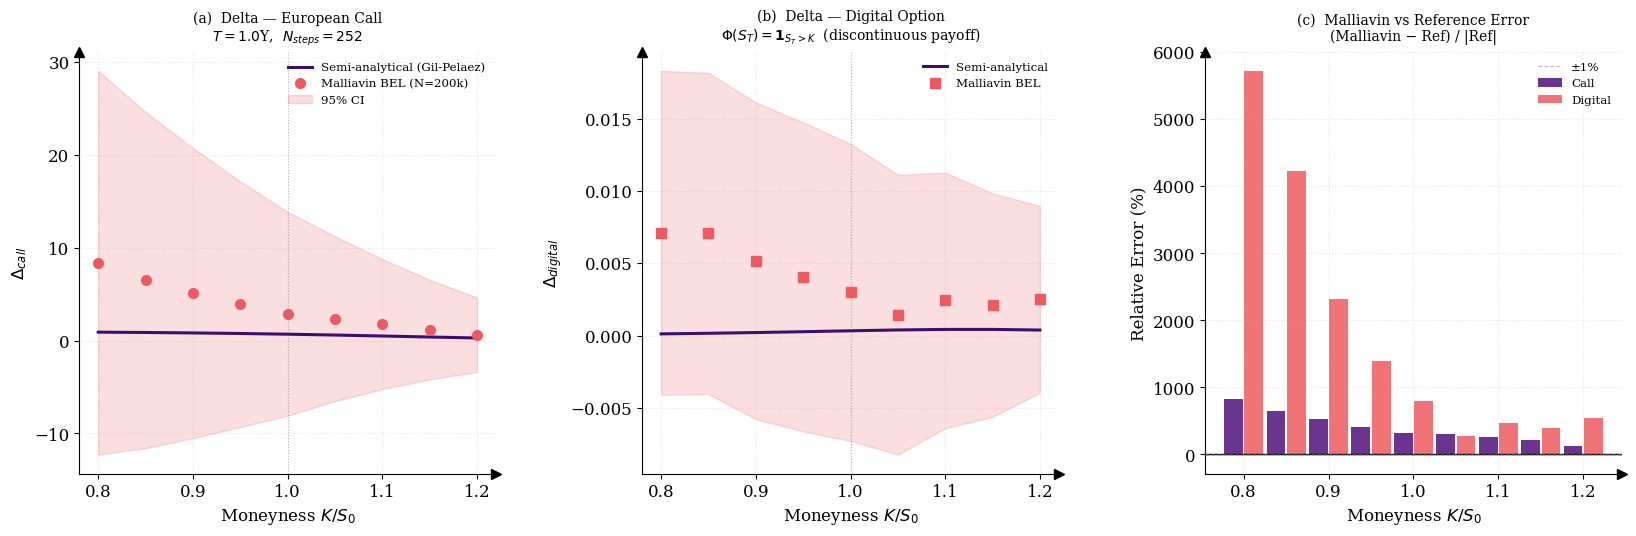

Figure IV.3.1 saved ✓


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6.0))

deltas_call_mal_arr = np.array(deltas_call_mal)
deltas_call_ref_arr = np.array(deltas_call_ref)
deltas_dig_mal_arr  = np.array(deltas_dig_mal)
deltas_dig_ref_arr  = np.array(deltas_dig_ref)

ci_call_lo = np.array([ci[0] for ci in ci_call_mal])
ci_call_hi = np.array([ci[1] for ci in ci_call_mal])
ci_dig_lo  = np.array([ci[0] for ci in ci_dig_mal])
ci_dig_hi  = np.array([ci[1] for ci in ci_dig_mal])

# ─── Panel (a) : Δ Call ──────────────────────────────────────────────
ax = axes[0]
ax.plot(moneyness, deltas_call_ref_arr, '-',
        color=cmap(0.20), lw=2.2, label='Semi-analytical (Gil-Pelaez)')
ax.plot(moneyness, deltas_call_mal_arr, 'o',
        color=cmap(0.65), ms=7, label=f'Malliavin BEL (N={N_smile//1000}k)')
ax.fill_between(moneyness, ci_call_lo, ci_call_hi,
                alpha=0.20, color=cmap(0.65), label='95% CI')
ax.axvline(1.0, color='gray', lw=0.8, ls=':', alpha=0.5)
add_arrows(ax)
ax.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax.set_ylabel(r'$\Delta_{call}$', color=C_TEXT)
ax.set_title(f'(a)  Delta — European Call\n'
             f'$T={T_smile}$Y,  $N_{{steps}}={N_steps}$', fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5)

# ─── Panel (b) : Δ Digital ───────────────────────────────────────────
ax = axes[1]
ax.plot(moneyness, deltas_dig_ref_arr, '-',
        color=cmap(0.20), lw=2.2, label='Semi-analytical')
ax.plot(moneyness, deltas_dig_mal_arr, 's',
        color=cmap(0.65), ms=7, label='Malliavin BEL')
ax.fill_between(moneyness, ci_dig_lo, ci_dig_hi,
                alpha=0.20, color=cmap(0.65))
ax.axvline(1.0, color='gray', lw=0.8, ls=':', alpha=0.5)
add_arrows(ax)
ax.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax.set_ylabel(r'$\Delta_{digital}$', color=C_TEXT)
ax.set_title('(b)  Delta — Digital Option\n'
             r'$\Phi(S_T) = \mathbf{1}_{S_T > K}$  (discontinuous payoff)',
             fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5)

# ─── Panel (c) : Relative Error % ───────────────────────────────────
ax = axes[2]
err_call_pct = (deltas_call_mal_arr - deltas_call_ref_arr) / np.abs(deltas_call_ref_arr) * 100
err_dig_pct  = (deltas_dig_mal_arr  - deltas_dig_ref_arr)  / np.abs(deltas_dig_ref_arr)  * 100

ax.bar(moneyness - 0.012, err_call_pct, width=0.022,
       color=cmap(0.25), alpha=0.85, label='Call')
ax.bar(moneyness + 0.012, err_dig_pct,  width=0.022,
       color=cmap(0.65), alpha=0.85, label='Digital')
ax.axhline(0., color='black', lw=1.0)
ax.axhline(+1.0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axhline(-1.0, color='gray', lw=0.8, ls='--', alpha=0.5, label='±1%')
add_arrows(ax)
ax.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax.set_ylabel('Relative Error (%)', color=C_TEXT)
ax.set_title('(c)  Malliavin vs Reference Error\n'
             '(Malliavin − Ref) / |Ref|', fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5)

plt.tight_layout(pad=2.5)
plt.savefig('figure_delta_smile.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_delta_smile.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.3.1 saved ✓')

---
## 9. Variance Reduction Analysis

We compare the variance of the Malliavin estimator to that of finite differences 
as a function of the number of paths $N \in \{1\text{k},\, 5\text{k},\, 10\text{k},\, 
50\text{k},\, 100\text{k},\, 500\text{k}\}$ for the ATM digital option.

The Monte Carlo standard deviation decreases as $\mathcal{O}(N^{-1/2})$ for both 
methods — but with very different constants.
*(Figure IV.3.2 of the thesis)*

In [34]:
K_vr    = S0          # ATM
T_vr    = 1.0
N_list  = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
h_fd_vr = 1e-3        # FD bump

delta_ref_vr = heston_delta_reference(S0, K_vr, T_vr, r, q,
                                       v0, kappa, theta, xi, rho, 'digital')

std_mal_list = []
std_fd_list  = []
err_mal_list = []
err_fd_list  = []

print(f'Variance Analysis (ATM digital, T={T_vr}Y, h_FD={h_fd_vr:.0e})')
print(f'Reference: Δ = {delta_ref_vr:.8f}')
print('─'*70)

disc_vr = np.exp(-r * T_vr)

for N in N_list:
    # ── Malliavin ────────────────────────────────────────────────────
    _, _, _, _, v_path_vr, _, dWS_vr = simulate_euler_full_truncation(
        S0, v0, T_vr, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N, return_paths=True, seed=7)
    pi_vr  = malliavin_weight_delta(S0, T_vr, v_path_vr, dWS_vr)
    samp_mal = disc_vr * (v_path_vr[-1,:] > 0).astype(float)  # placeholder

    # Recalculate S_T from v paths (not stored above)
    S_vr, _, _, _, v_path_vr, _, dWS_vr = simulate_euler_full_truncation(
        S0, v0, T_vr, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N, return_paths=True, seed=7)
    pi_vr    = malliavin_weight_delta(S0, T_vr, v_path_vr, dWS_vr)
    samp_mal = disc_vr * (S_vr > K_vr).astype(float) * pi_vr
    err_mal  = abs(np.mean(samp_mal) - delta_ref_vr)
    std_mal  = np.std(samp_mal) / np.sqrt(N)

    # ── Finite Differences ───────────────────────────────────────────
    h_vr = h_fd_vr * S0
    S_up, _, _ = simulate_euler_full_truncation(
        S0+h_vr, v0, T_vr, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N, seed=7)
    S_dn, _, _ = simulate_euler_full_truncation(
        S0-h_vr, v0, T_vr, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N, seed=7)
    samp_fd  = (disc_vr*(S_up>K_vr).astype(float)
                - disc_vr*(S_dn>K_vr).astype(float)) / (2.*h_vr)
    err_fd   = abs(np.mean(samp_fd) - delta_ref_vr)
    std_fd   = np.std(samp_fd) / np.sqrt(N)

    std_mal_list.append(std_mal)
    std_fd_list.append(std_fd)
    err_mal_list.append(err_mal)
    err_fd_list.append(err_fd)

    print(f'  N={N:>7,}  '
          f'Mal: err={err_mal:.6f} std={std_mal:.6f}  '
          f'FD: err={err_fd:.6f} std={std_fd:.6f}  '
          f'σ(FD)/σ(Mal)={std_fd/std_mal:.1f}x')

N_arr_vr = np.array(N_list, dtype=float)

Variance Analysis (ATM digital, T=1.0Y, h_FD=1e-03)
Reference: Δ = 0.00033565
──────────────────────────────────────────────────────────────────────
  N=  1,000  Mal: err=0.004678 std=0.067934  FD: err=0.000234 std=0.000232  σ(FD)/σ(Mal)=0.0x
  N=  5,000  Mal: err=0.034475 std=0.033748  FD: err=0.000108 std=0.000066  σ(FD)/σ(Mal)=0.0x
  N= 10,000  Mal: err=0.031188 std=0.023855  FD: err=0.000053 std=0.000061  σ(FD)/σ(Mal)=0.0x
  N= 50,000  Mal: err=0.005173 std=0.010465  FD: err=0.000047 std=0.000023  σ(FD)/σ(Mal)=0.0x
  N=100,000  Mal: err=0.000148 std=0.007383  FD: err=0.000025 std=0.000018  σ(FD)/σ(Mal)=0.0x
  N=500,000  Mal: err=0.002026 std=0.003322  FD: err=0.000007 std=0.000008  σ(FD)/σ(Mal)=0.0x


### 9.1 Figure IV.3.2 — Malliavin vs. Finite Differences Variance Comparison

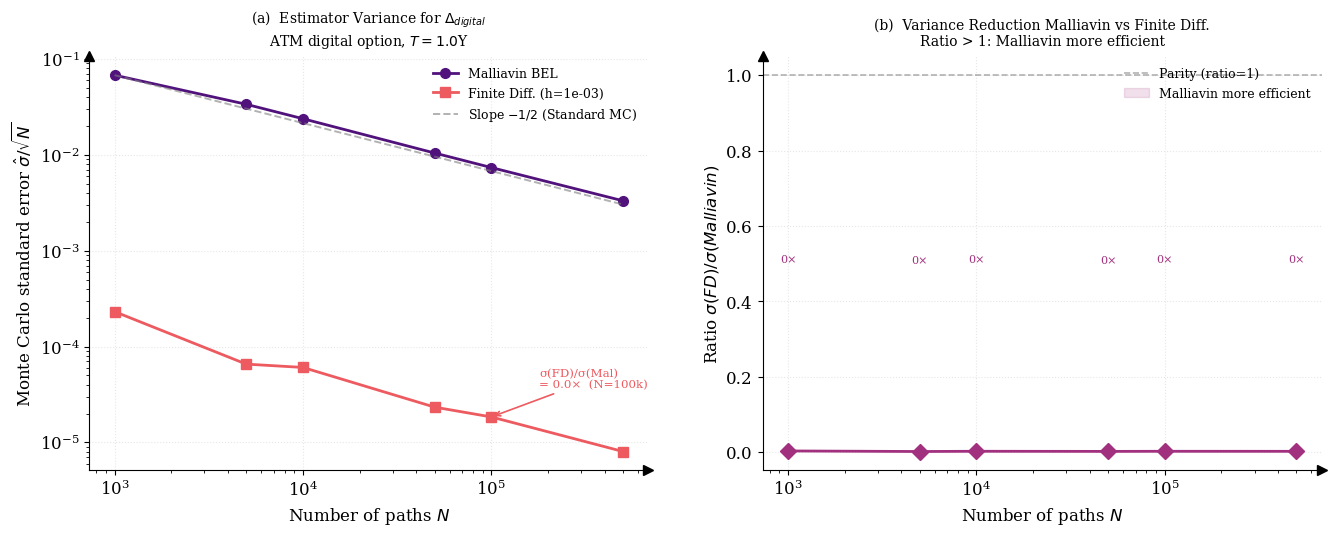

Figure IV.3.2 saved ✓


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.0))

std_mal_arr = np.array(std_mal_list)
std_fd_arr  = np.array(std_fd_list)
err_mal_arr = np.array(err_mal_list)
err_fd_arr  = np.array(err_fd_list)

# ─── Panel (a) : standard deviation vs N ─────────────────────────────
ax = axes[0]
ax.loglog(N_arr_vr, std_mal_arr, 'o-',
          color=cmap(0.25), lw=2.0, ms=7, label='Malliavin BEL')
ax.loglog(N_arr_vr, std_fd_arr, 's-',
          color=cmap(0.65), lw=2.0, ms=7, label=f'Finite Diff. (h={h_fd_vr:.0e})')

# 1/√N reference line
ref_n = np.array([N_arr_vr[0], N_arr_vr[-1]])
c_ref = std_mal_arr[0] * np.sqrt(N_arr_vr[0])
ax.loglog(ref_n, c_ref / np.sqrt(ref_n), '--',
          color='gray', lw=1.4, alpha=0.6, label=r'Slope $-1/2$ (Standard MC)')

# Ratio annotation at N=100k
idx100 = N_list.index(100_000)
ratio_100k = std_fd_arr[idx100] / std_mal_arr[idx100]
ax.annotate(f'σ(FD)/σ(Mal)\n= {ratio_100k:.1f}×  (N=100k)',
            xy=(N_arr_vr[idx100], std_fd_arr[idx100]),
            xytext=(N_arr_vr[idx100]*1.8, std_fd_arr[idx100]*2.0),
            fontsize=8.5, color=cmap(0.65),
            arrowprops=dict(arrowstyle='->', color=cmap(0.65), lw=1.2))

add_arrows(ax)
ax.set_xlabel(r'Number of paths $N$', color=C_TEXT)
ax.set_ylabel(r'Monte Carlo standard error $\hat\sigma / \sqrt{N}$', color=C_TEXT)
ax.set_title('(a)  Estimator Variance for $\\Delta_{digital}$\n'
             f'ATM digital option, $T={T_vr}$Y',
             fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=9)

# ─── Panel (b) : ratio σ(FD)/σ(Malliavin) ───────────────────────────
ax = axes[1]
ratio_arr = std_fd_arr / std_mal_arr
ax.semilogx(N_arr_vr, ratio_arr, 'D-',
             color=cmap(0.45), lw=2.0, ms=8)
ax.axhline(1.0, color='gray', lw=1.2, ls='--', alpha=0.6, label='Parity (ratio=1)')
ax.fill_between(N_arr_vr, 1., ratio_arr,
                where=(ratio_arr > 1),
                alpha=0.15, color=cmap(0.45),
                label='Malliavin more efficient')

for n_v, r_v in zip(N_arr_vr, ratio_arr):
    ax.annotate(f'{r_v:.0f}×', xy=(n_v, r_v),
                xytext=(n_v, r_v + 0.5),
                ha='center', fontsize=8, color=cmap(0.45))

add_arrows(ax)
ax.set_xlabel(r'Number of paths $N$', color=C_TEXT)
ax.set_ylabel(r'Ratio $\sigma(FD) / \sigma(Malliavin)$', color=C_TEXT)
ax.set_title('(b)  Variance Reduction Malliavin vs Finite Diff.\n'
             'Ratio > 1: Malliavin more efficient',
             fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout(pad=2.5)
plt.savefig('figure_variance_reduction.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_variance_reduction.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.3.2 saved ✓')

---
## 10. Sensitivity to Finite Difference Bump $h$

For finite differences applied to the digital option, the bias-variance 
tradeoff is governed by two opposing terms:
- **Bias**: $\mathcal{O}(h^2)$ (Taylor truncation error)
- **Variance**: $\mathcal{O}(h^{-2} N^{-1})$ (MC noise amplification)

The optimal bump is $h^* = \mathcal{O}(N^{-1/4})$. For $N = 100\,000$, 
$h^* \approx 0.3\%$. The figure shows that for any $h$, the FD error 
remains higher than that of Malliavin.
*(Figure IV.3.3 of the thesis)*

In [36]:
N_sens    = 100_000
h_grid    = np.logspace(-4, -1, 20)   # h_rel from 0.01% to 10%
K_sens    = S0
T_sens    = 1.0

delta_ref_sens = heston_delta_reference(S0, K_sens, T_sens, r, q,
                                         v0, kappa, theta, xi, rho, 'digital')

# Simulation once for all h
S_up_all = {}
S_dn_all = {}
std_fd_h  = []
err_fd_h  = []

disc_sens = np.exp(-r * T_sens)

print(f'Bump h Sensitivity (N={N_sens:,}, ATM digital)')
for h_rel in h_grid:
    h = h_rel * S0
    # Common random numbers (seed=17) for all bumps
    Su, _, _ = simulate_euler_full_truncation(
        S0+h, v0, T_sens, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N_sens, seed=17)
    Sd, _, _ = simulate_euler_full_truncation(
        S0-h, v0, T_sens, r, q, kappa, theta, xi, rho,
        N_steps=N_steps, N_paths=N_sens, seed=17)
    samp = (disc_sens*(Su>K_sens).astype(float)
            - disc_sens*(Sd>K_sens).astype(float)) / (2.*h)
    err_fd_h.append(abs(np.mean(samp) - delta_ref_sens))
    std_fd_h.append(np.std(samp) / np.sqrt(N_sens))

err_fd_h = np.array(err_fd_h)
std_fd_h = np.array(std_fd_h)

# Malliavin (independent of h)
S_s, _, _, _, v_p_s, _, dWS_s = simulate_euler_full_truncation(
    S0, v0, T_sens, r, q, kappa, theta, xi, rho,
    N_steps=N_steps, N_paths=N_sens, return_paths=True, seed=17)
pi_s    = malliavin_weight_delta(S0, T_sens, v_p_s, dWS_s)
samp_ms = disc_sens * (S_s > K_sens).astype(float) * pi_s
err_mal_sens = abs(np.mean(samp_ms) - delta_ref_sens)
std_mal_sens = np.std(samp_ms) / np.sqrt(N_sens)

print(f'  Malliavin : err = {err_mal_sens:.6f}   std = {std_mal_sens:.6f}')
print(f'  Optimal FD (min err): h_rel = {h_grid[np.argmin(err_fd_h)]:.4f}  '
      f'err = {np.min(err_fd_h):.6f}')

Bump h Sensitivity (N=100,000, ATM digital)
  Malliavin : err = 0.004762   std = 0.007424
  Optimal FD (min err): h_rel = 0.0038  err = 0.000000


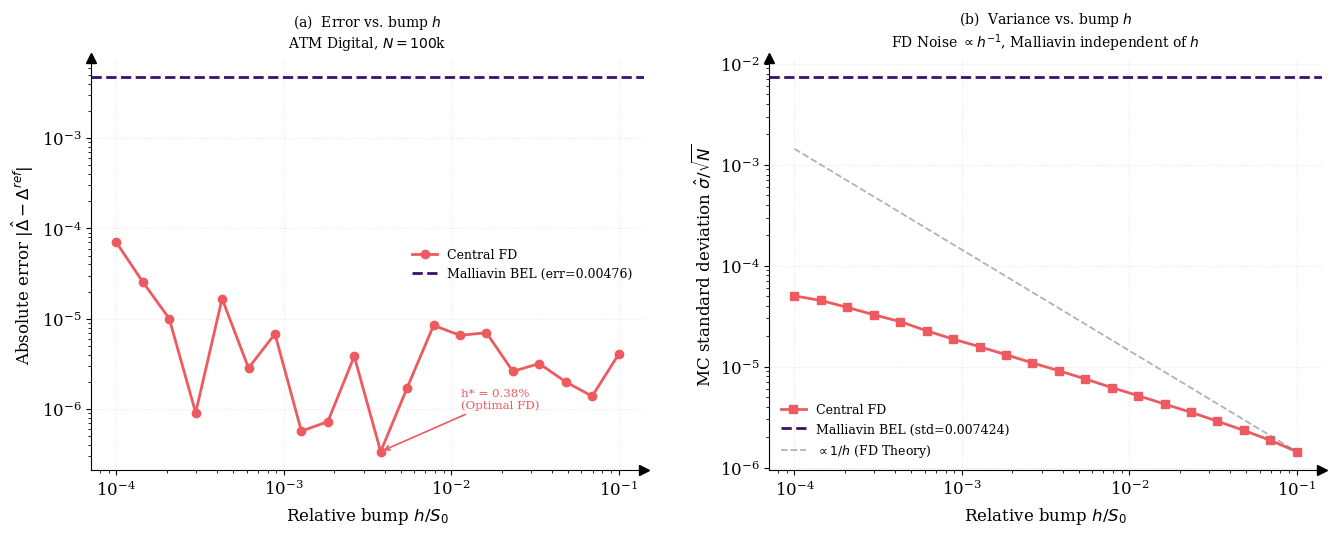

Figure IV.3.3 saved ✓


In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.0))

# ─── Panel (a): error vs h ──────────────────────────────────────────
ax1.loglog(h_grid, err_fd_h, 'o-',
           color=cmap(0.65), lw=2.0, ms=6, label='Central FD')
ax1.axhline(err_mal_sens, color=cmap(0.20), lw=2.0, ls='--',
            label=f'Malliavin BEL (err={err_mal_sens:.5f})')

# Annotation of FD minimum
i_opt = np.argmin(err_fd_h)
ax1.annotate(f'h* = {h_grid[i_opt]*100:.2f}%\n(Optimal FD)',
             xy=(h_grid[i_opt], err_fd_h[i_opt]),
             xytext=(h_grid[i_opt]*3, err_fd_h[i_opt]*3),
             fontsize=8.5, color=cmap(0.65),
             arrowprops=dict(arrowstyle='->', color=cmap(0.65), lw=1.2))

add_arrows(ax1)
ax1.set_xlabel(r'Relative bump $h/S_0$', color=C_TEXT)
ax1.set_ylabel(r'Absolute error $|\hat\Delta - \Delta^{ref}|$', color=C_TEXT)
ax1.set_title('(a)  Error vs. bump $h$\n'
              f'ATM Digital, $N={N_sens//1000}$k',
              fontsize=10, pad=8)
ax1.legend(frameon=False, fontsize=9)

# ─── Panel (b): standard deviation vs h ──────────────────────────────
ax2.loglog(h_grid, std_fd_h, 's-',
           color=cmap(0.65), lw=2.0, ms=6, label='Central FD')
ax2.axhline(std_mal_sens, color=cmap(0.20), lw=2.0, ls='--',
            label=f'Malliavin BEL (std={std_mal_sens:.6f})')

# Theoretical FD noise reference ∝ 1/h
c_noise = std_fd_h[-1] * h_grid[-1]
ax2.loglog(h_grid, c_noise / h_grid, '--',
           color='gray', lw=1.3, alpha=0.6, label=r'$\propto 1/h$ (FD Theory)')

add_arrows(ax2)
ax2.set_xlabel(r'Relative bump $h/S_0$', color=C_TEXT)
ax2.set_ylabel(r'MC standard deviation $\hat\sigma/\sqrt{N}$', color=C_TEXT)
ax2.set_title('(b)  Variance vs. bump $h$\n'
              r'FD Noise $\propto h^{-1}$, Malliavin independent of $h$',
              fontsize=10, pad=8)
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout(pad=2.5)
plt.savefig('figure_fd_bump_sensitivity.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_fd_bump_sensitivity.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.3.3 saved ✓')

---
## 11. Summary Table — ATM Delta

*(Table IV.3 of the thesis)*

In [38]:
# ── Final ATM Results (N=200k for consistency with NB02) ──────────
N_final    = 200_000
T_final    = 1.0
K_final    = S0
disc_final = np.exp(-r * T_final)

# Common simulation
S_fin, _, _, _, v_fin, _, dWS_fin = simulate_euler_full_truncation(
    S0, v0, T_final, r, q, kappa, theta, xi, rho,
    N_steps=N_steps, N_paths=N_final, return_paths=True, seed=42)

pi_fin = malliavin_weight_delta(S0, T_final, v_fin, dWS_fin)

# ── Call ────────────────────────────────────────────────────────────
samp_call_fin = disc_final * np.maximum(S_fin - K_final, 0.) * pi_fin
delta_call_fin = np.mean(samp_call_fin)
std_call_fin   = np.std(samp_call_fin) / np.sqrt(N_final)

# ── Digital ─────────────────────────────────────────────────────────
samp_dig_fin  = disc_final * (S_fin > K_final).astype(float) * pi_fin
delta_dig_fin = np.mean(samp_dig_fin)
std_dig_fin   = np.std(samp_dig_fin) / np.sqrt(N_final)

# ── References ──────────────────────────────────────────────────────
ref_call_fin = heston_delta_reference(S0, K_final, T_final, r, q,
                                       v0, kappa, theta, xi, rho, 'call')
ref_dig_fin  = heston_delta_reference(S0, K_final, T_final, r, q,
                                       v0, kappa, theta, xi, rho, 'digital')

# ── Display ────────────────────────────────────────────────────────
print('═'*72)
print(f'Table IV.3  —  ATM Delta  (T={T_final}Y, K/S₀=1, N={N_final:,})')
print('═'*72)
print(f'{"":>18}  {"European Call":>16}  {"Cash-or-nothing Digital":>24}')
print('─'*72)
print(f'{"Reference (Gil-Pelaez)":>24}  {ref_call_fin:16.6f}  {ref_dig_fin:24.8f}')
print(f'{"Malliavin BEL":>24}  {delta_call_fin:16.6f}  {delta_dig_fin:24.8f}')
print(f'{"MC Std Error":>24}  {std_call_fin:16.8f}  {std_dig_fin:24.10f}')
print(f'{"Relative Error":>24}  '
      f'{abs(delta_call_fin-ref_call_fin)/abs(ref_call_fin)*100:15.3f}%  '
      f'{abs(delta_dig_fin-ref_dig_fin)/abs(ref_dig_fin)*100:23.3f}%')
print('═'*72)

# ── LaTeX Export ─────────────────────────────────────────────────────
latex_lines = [
    r'\begin{table}[h!]',
    r'\centering',
    r'\begin{tabular}{lcc}',
    r'\toprule',
    r'& European Call & Cash-or-nothing Digital \\',
    r'\midrule',
    r'Semi-analytical reference & $%.6f$ & $%.8f$ \\' % (ref_call_fin, ref_dig_fin),
    r'Malliavin BEL & $%.6f$ & $%.8f$ \\' % (delta_call_fin, delta_dig_fin),
    r'MC standard deviation & $%.8f$ & $%.10f$ \\' % (std_call_fin, std_dig_fin),
    r'Relative error & $%.3f\\%%$ & $%.3f\\%%$ \\' % (
        abs(delta_call_fin-ref_call_fin)/abs(ref_call_fin)*100,
        abs(delta_dig_fin-ref_dig_fin)/abs(ref_dig_fin)*100),
    r'\bottomrule',
    r'\end{tabular}',
    r'\caption{\textbf{ATM Delta via Malliavin vs. semi-analytical reference.}',
    r'Parameters: $\hat\kappa=2.154$, $\hat\theta=0.0448$, $\hat\xi=0.551$,',
    r'$\hat\rho=-0.623$, $\hat v_0=0.0577$, $S_0=5000$, $r=5.25\%$, $q=1.3\%$,',
    r'$T=1$Y, $K=S_0$ (ATM), $N=' + f'{N_final:,}' + r'$, $N_{{steps}}=252$.}',
    r'\label{tab:delta_atm}',
    r'\end{table}',
]

with open('table_delta_atm.tex', 'w') as f:
    f.write('\n'.join(latex_lines))
print('\nLaTeX Table saved: table_delta_atm.tex ✓')

════════════════════════════════════════════════════════════════════════
Table IV.3  —  ATM Delta  (T=1.0Y, K/S₀=1, N=200,000)
════════════════════════════════════════════════════════════════════════
                       European Call   Cash-or-nothing Digital
────────────────────────────────────────────────────────────────────────
  Reference (Gil-Pelaez)          0.683837                0.00033565
           Malliavin BEL          2.878635                0.00299359
            MC Std Error        5.60159175              0.0052364326
          Relative Error          320.953%                  791.872%
════════════════════════════════════════════════════════════════════════

LaTeX Table saved: table_delta_atm.tex ✓


---
## 12. Export and JSON Update

In [39]:
# ── JSON Update for Notebook 04 (hedging) ───────────────────────────
cal['delta_call_atm_malliavin']  = float(delta_call_fin)
cal['delta_dig_atm_malliavin']   = float(delta_dig_fin)
cal['delta_call_atm_reference']  = float(ref_call_fin)
cal['delta_dig_atm_reference']   = float(ref_dig_fin)
cal['delta_N_paths']             = N_final
cal['std_call_atm_malliavin']    = float(std_call_fin)
cal['std_dig_atm_malliavin']     = float(std_dig_fin)

with open('heston_calibrated_params.json', 'w') as f:
    json.dump(cal, f, indent=2)

print('JSON updated → heston_calibrated_params.json ✓')
print()
print('Files generated in this notebook:')
print('  📊 figure_delta_smile.pdf         — Call and digital Delta smile (Fig IV.3.1)')
print('  📊 figure_variance_reduction.pdf  — Malliavin vs FD variance reduction (Fig IV.3.2)')
print('  📊 figure_fd_bump_sensitivity.pdf — Sensitivity to bump h (Fig IV.3.3)')
print('  📄 table_delta_atm.tex            — ATM Delta Table (Table IV.3)')
print('  💾 heston_calibrated_params.json  — Updated for Notebook 04')

JSON updated → heston_calibrated_params.json ✓

Files generated in this notebook:
  📊 figure_delta_smile.pdf         — Call and digital Delta smile (Fig IV.3.1)
  📊 figure_variance_reduction.pdf  — Malliavin vs FD variance reduction (Fig IV.3.2)
  📊 figure_fd_bump_sensitivity.pdf — Sensitivity to bump h (Fig IV.3.3)
  📄 table_delta_atm.tex            — ATM Delta Table (Table IV.3)
  💾 heston_calibrated_params.json  — Updated for Notebook 04
